In [57]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import pandas as pd
import re
import pandas as pd
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from google.colab import auth
from google.auth import default
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.optimize import minimize


## Simple Bacterial Growth Model


In [58]:
def Monod(y, t, rho, muK):
    R, B = y
    this_K = 1.0
    m = muK * this_K
    dydt = [-m * R / (this_K + R) * B, rho * m * R / (this_K + R) * B]
    return dydt

def simulate_model(rho, muK, y0, t):
    solution = odeint(Monod, y0, t, args=(rho, muK))
    R, B = solution.T
    return t, B

## Curve Fitting

In [59]:
def CFUs(ODs):
    b1 = 1002614811.71
    b2 = 12526559.79
    return b1 * ODs + b2

def model_fit( t, rho, muK, strain):

    initial_R = 1.0  # Assume some initial resource concentration
    initial_B = data[strain + ' MeanOD'].iloc[0]  # Use the first measurement as initial bacterial density
    y0 = [initial_R, initial_B]
    _, B = simulate_model(rho, muK, y0, t)
    return B

def print_fit_results(popt, pcov):
    # Parameters are rho and muK
    rho, muK = popt
    print(f"Optimized Parameters:")
    print(f"rho (resource conversion rate): {rho:.4e}")  # Exponential notation for readability
    print(f"muK (mu/K parameter): {muK:.4e}")

    # Print the covariance matrix
    #print("\nCovariance Matrix of the Parameters:")
    #print(pcov)

    # Optionally, you could also print the standard deviations of the parameters
    # which are the square roots of the diagonal elements of the covariance matrix
    perr = np.sqrt(np.diag(pcov))  # Standard deviations of the parameters
    print(f"Std of rho: {perr[0]:.4e}")
    print(f"Std of muK: {perr[1]:.4e}")



In [60]:
def plot_od_sim(df, strain, popt):
    """
    Plot the optical density data with error bars and overlay the model predictions.

    Parameters:
    - df: DataFrame containing the data.
    - strain: The strain name to use for labeling the data.
    - popt: Tuple of fitted parameters (rho, muK).
    """
    # Extract experimental data
    time = df['Time (h)']

    mean_od = df[strain + ' MeanOD']
    std_od = df[strain + ' StdOD']


    # Calculate the standard error of the mean (SEM)
    sample_size = 3  # Adjust this if you have a different number of replicates
    sem = std_od / np.sqrt(sample_size)

    # Simulate the model with the optimized parameters
    initial_conditions = [1.0, mean_od.iloc[0]]  # Assuming some initial resource and the initial OD from your data
    simulated_t, simulated_B = simulate_model(*popt, initial_conditions, time.values)

    # Create the plot
    plt.figure(figsize=(6, 4))
    label=strain.replace('Jing', 'Mutant ')
    # Plot experimental data
    plt.errorbar(time, mean_od, yerr=sem, fmt='.-',color='grey', ecolor='grey', capsize=2, label=f'{label}')

    # Plot model predictions
    plt.plot(simulated_t, simulated_B, label='Model fit', linestyle='-', marker='', color='k', lw=3)

    plt.xlabel('Time (hours)')
    plt.ylabel('Density (cells/ml)')

    plt.title(f' {label}')
    plt.legend()
    plt.grid(False)  # Optionally turn off the grid
    plt.show()


In [61]:
def export_monod_parameters(sheet_url, tab_name, strain, rho, muK):
    # Authenticate and create the client
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)

    # Open the worksheet by URL
    sh = gc.open_by_url(sheet_url)

    # Check if worksheet exists, if not create it and set headers
    try:
        worksheet = sh.worksheet(tab_name)
    except gspread.WorksheetNotFound:
        worksheet = sh.add_worksheet(title=tab_name, rows="100", cols="20")
        headers = ['name', 'color', 'specie', 'strain', 'type', 'PCN', 'MIC', 'conj_rate', 'VKm', 'rho', 'seg_rate', 'kappa', 'beta', 'chi','colistin']
        worksheet.append_row(headers)  # Append the headers once when creating the worksheet

    # Check if the strain name contains '_Colistin' and remove it
    contains_colistin = '_Colistin' in strain
    modified_strain = strain.replace('_Colistin', '')

    # Determine the type based on the content within parentheses in the modified strain name
    type_match = re.search(r'\(([^)]+)\)', modified_strain)
    if type_match:
        type_strain = type_match.group(1)
    else:
        type_strain = 'WT'

    # Clean the strain name by removing any parenthetical content
    clean_strain = re.sub(r'\(.*\)', '', modified_strain).strip()

    # Determine the color based on the strain prefix
    strain_to_color = {'J53': '#FF0000', 'WJ1': '#00FF00', 'E30': '#0000FF'}  # Example color mapping
    color = next((strain_to_color[key] for key in strain_to_color if clean_strain.startswith(key)), '')

    # Prepare data with defaults and specific values
    data_values = {
        **default_parameters,
        'name': clean_strain,
        'color': color,
        'specie': '',
        'strain': clean_strain,
        'type': type_strain,
        'VKm': f"{muK:.4e}",
        'rho': f"{rho:.4e}",
        'colistin': contains_colistin
    }

    # Prepare the data to be appended using the header order
    headers = worksheet.row_values(1)  # Assuming the first row contains headers
    data = [data_values.get(header, '') for header in headers]

    # Append the data to the worksheet
    worksheet.append_row(data)

    print("Monod parameters exported successfully")

In [62]:
default_parameters = {
    'color': '#000000',
    'specie': 'X',
    'PCN': 2,
    'MIC': 0.5,
    'conj_rate': 1e-3,
    'seg_rate': 0.002,
    'kappa': 1.00E-04,
    'beta':0.5,
    'chi':1
}
strain_to_color = {
    'J53': '#FF0000',  # Red
    'WJ1': '#00FF00',  # Green
    'E30': '#0000FF'   # Blue
}

In [63]:
def load_data(sheet_url, tab_name, strain):
    # Authenticate and create the client
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)

    # Open the worksheet by URL and get the specific tab by name
    sh = gc.open_by_url(sheet_url)
    worksheet = sh.worksheet(tab_name)  # Ensure tab name is correct

    # Get all the data from the sheet
    data = worksheet.get_all_values()

    # Convert to DataFrame
    headers = data[0]  # Assumes the first row is headers
    df = pd.DataFrame(data[1:], columns=headers)

    # Convert the first column to numeric for time, if it's the time column
    if 'Time (h)' in df.columns:
        df['Time (h)'] = pd.to_numeric(df['Time (h)'], errors='coerce')

    # Filter columns by exact strain name match and convert them to numeric
    strain_columns = [col for col in df.columns if col.strip() == strain]
    print("Matching Columns:", strain_columns)  # Debug: Show matching columns

    if not strain_columns:
        print(f"No columns found for strain {strain}.")
        return None

    # Handle each column by its position to ensure uniqueness
    for i, col in enumerate(df.columns):
        if col.strip() == strain:
            df.iloc[:, i] = pd.to_numeric(df.iloc[:, i], errors='coerce')

    # If there are multiple columns for the strain, calculate their mean and std
    if len(strain_columns) > 1:
        df_mean = df[strain_columns].mean(axis=1)
        df_std = df[strain_columns].std(axis=1)
    else:
        df_mean = df[strain_columns[0]]  # Only one column data directly used as mean
        df_std = pd.Series([0] * len(df), index=df.index)  # Std is zero since there's no variation

    result = pd.DataFrame({
        'Time (h)': df['Time (h)'],
        strain + ' MeanOD': CFUs(df_mean),
        strain + ' StdOD': CFUs(df_std)
    })

    return result


In [64]:

# Example usage
sheet_url = 'https://docs.google.com/spreadsheets/d/1nAyi0XfzWstjuXvePPPcXTNLWUyeztl7TNH2b4CKrbw'
#strains={'E30','WJ1','J53(pE30)','J53(pWJ1)','J53','E30_Colistin','WJ1_Colistin','J53(pE30)_Colistin','J53(pWJ1)_Colistin'} #,,'J53_Colistin'
strains = [f'Jing{i}' for i in range(2, 10)]  # Generates ['Jing 1', 'Jing 2', ..., 'Jing 8']
#strains.append('J53(pWJ1)')
growth_params={}



** Strain: Mutant 2 **
Matching Columns: ['Jing2']
Optimized Parameters:
rho (resource conversion rate): 1.1984e+09
muK (mu/K parameter): 5.8160e-10
Std of rho: 8.0769e+06
Std of muK: 1.0928e-11


** Strain: Mutant 3 **
Matching Columns: ['Jing3']
Optimized Parameters:
rho (resource conversion rate): 1.0579e+09
muK (mu/K parameter): 5.9105e-10
Std of rho: 8.2777e+06
Std of muK: 1.3685e-11


** Strain: Mutant 4 **
Matching Columns: ['Jing4']
Optimized Parameters:
rho (resource conversion rate): 1.1695e+09
muK (mu/K parameter): 7.5574e-10
Std of rho: 9.0802e+06
Std of muK: 1.5878e-11


** Strain: Mutant 5 **
Matching Columns: ['Jing5']
Optimized Parameters:
rho (resource conversion rate): 1.5229e+09
muK (mu/K parameter): 4.0144e-10
Std of rho: 1.4839e+07
Std of muK: 9.1871e-12


** Strain: Mutant 6 **
Matching Columns: ['Jing6']
Optimized Parameters:
rho (resource conversion rate): 1.7883e+09
muK (mu/K parameter): 3.4076e-10
Std of rho: 2.2469e+07
Std of muK: 9.5824e-12


** Strain: Mu

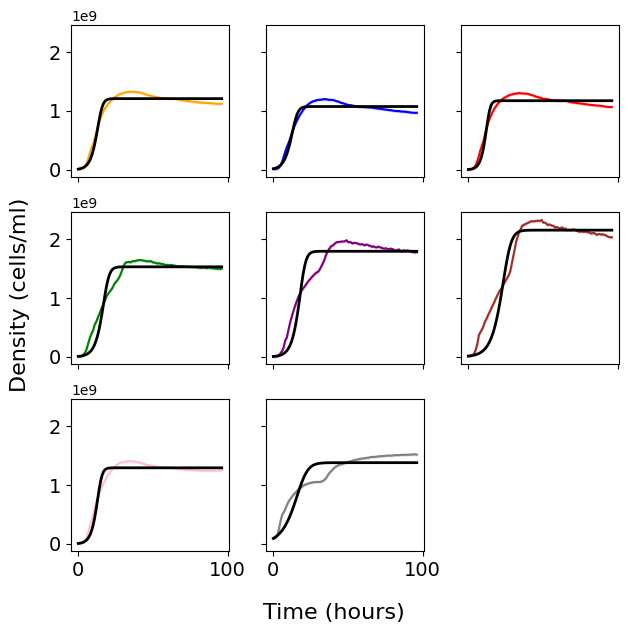

In [65]:
def plot_od_sim(ax, df, strain, popt, color):
    try:
        # Extract experimental data
        time = pd.to_numeric(df['Time (h)'], errors='coerce').values
        mean_od = pd.to_numeric(df[strain + ' MeanOD'], errors='coerce').values
        std_od = pd.to_numeric(df[strain + ' StdOD'], errors='coerce').values

        # Check for NaNs or Infs
        if not (np.all(np.isfinite(time)) and np.all(np.isfinite(mean_od)) and np.all(np.isfinite(std_od))):
            raise ValueError(f"Non-numeric or invalid values detected for {strain}.")

        # Simulate the model with the optimized parameters
        initial_conditions = [1.0, mean_od[0]]  # Assuming some initial resource and the initial OD from your data
        simulated_t, simulated_B = simulate_model(*popt, initial_conditions, time)

        if strain != 'Jing9':
              label = strain.replace('Jing', 'Mutant ')
        else:
              label = "J53(pWJ1)"

        # Plot experimental data with filled area for std
        ax.fill_between(time, mean_od - std_od, mean_od + std_od, color=color, alpha=0.2)
        ax.plot(time, mean_od, linestyle='-', color=color, label=f'{label}')

        # Plot model predictions
        ax.plot(simulated_t, simulated_B, linestyle='-', color='k', lw=2)

        #ax.legend(fontsize=12, loc='upper right')
        #ax.set_xlabel('Time (hours)', fontsize=14)
        #ax.set_ylabel('Density (cells/ml)', fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=14)  # Adjust font size for major ticks
        ax.tick_params(axis='both', which='minor', labelsize=14)  # Optional: Adjust for minor ticks


        ax.grid(False)

    except Exception as e:
        print(f"Error while plotting {strain}: {e}")


# Main plotting loop
colors = ['orange', 'blue', 'red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']  # List of colors
num_strains = len(strains)
cols = 3
rows = (num_strains + cols - 1) // cols  # Calculate the required number of rows for the grid

fig, axes = plt.subplots(rows, cols, figsize=(6, 6), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

for i, strain in enumerate(strains):
    if strain != 'Jing9':
      label = strain.replace('Jing', 'Mutant ')
    else:
      label = "J53(pWJ1)"
    print(f"\n\n** Strain: {label} **")
    tab_name_data = 'OD'
    data = load_data(sheet_url, tab_name_data, strain)

    if data is not None:
        time = data['Time (h)'].values
        mean_od = data[strain + ' MeanOD'].values

        popt, pcov = curve_fit(lambda t, rho, muK: model_fit(t, rho, muK, strain), time, mean_od, p0=[1e9, 1e-11])
        rho, muK = popt
        growth_params[strain] = {'rho': rho, 'muK': muK}
        print_fit_results(popt, pcov)

        plot_od_sim(axes[i], data, strain, popt, colors[i % len(colors)])  # Pass color to the function

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add shared axis labels
fig.text(0.5, -0.04, 'Time (hours)', ha='center', fontsize=16)
fig.text(-0.04, 0.5, 'Density (cells/ml)', va='center', rotation='vertical', fontsize=16)

fig.tight_layout()
plt.show()


Matching Columns: ['Jing6']
Optimized Parameters:
rho (resource conversion rate): 1.7883e+09
muK (mu/K parameter): 3.4076e-10
Std of rho: 2.2469e+07
Std of muK: 9.5824e-12


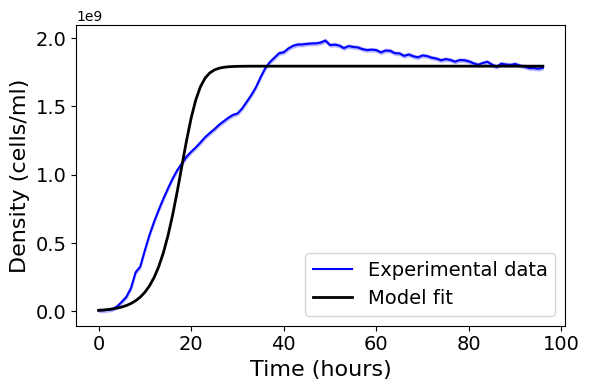

In [66]:


def plot_single_strain(df, strain, popt, color):
    """
    Plot the optical density data with error bars and overlay the model predictions for a single strain.

    Parameters:
    - df: DataFrame containing the data.
    - strain: The strain name to use for labeling the data.
    - popt: Tuple of fitted parameters (rho, muK).
    - color: Color for the line and shaded area.
    """
    try:
        # Extract experimental data
        time = pd.to_numeric(df['Time (h)'], errors='coerce').values
        mean_od = pd.to_numeric(df[strain + ' MeanOD'], errors='coerce').values
        std_od = pd.to_numeric(df[strain + ' StdOD'], errors='coerce').values

        # Check for NaNs or Infs
        if not (np.all(np.isfinite(time)) and np.all(np.isfinite(mean_od)) and np.all(np.isfinite(std_od))):
            raise ValueError(f"Non-numeric or invalid values detected for {strain}.")

        # Simulate the model with the optimized parameters
        initial_conditions = [1.0, mean_od[0]]  # Assuming some initial resource and the initial OD from your data
        simulated_t, simulated_B = simulate_model(*popt, initial_conditions, time)

        label = strain.replace('Jing', 'Mutant ')

        # Create the plot
        fig, ax = plt.subplots(figsize=(6, 4))

        # Plot experimental data with filled area for std
        ax.fill_between(time, mean_od - std_od, mean_od + std_od, color=color, alpha=0.2)
        ax.plot(time, mean_od, linestyle='-', color='blue', label=f'Experimental data')

        # Plot model predictions
        ax.plot(simulated_t, simulated_B, linestyle='-', color='k', lw=2, label='Model fit')

        # Customize plot appearance
        ax.set_xlabel('Time (hours)', fontsize=16)
        ax.set_ylabel('Density (cells/ml)', fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        ax.legend(fontsize=14)
        ax.grid(False)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error while plotting {strain}: {e}")


# Example usage
strain = "Jing6"  # Specify the strain you want to plot
label = 'Mutant 6'
tab_name_data = 'OD'
data = load_data(sheet_url, tab_name_data, strain)

if data is not None:
    time = data['Time (h)'].values
    mean_od = data[strain + ' MeanOD'].values

    popt, pcov = curve_fit(lambda t, rho, muK: model_fit(t, rho, muK, strain), time, mean_od, p0=[1e9, 1e-11])
    rho, muK = popt
    growth_params[strain] = {'rho': rho, 'muK': muK}
    print_fit_results(popt, pcov)

    plot_single_strain(data, strain, popt, color='blue')  # Adjust color as needed


## Drug-susceptibility parameter determination

First, we load the MIC data from a spreadsheet

In [67]:
def dB_kill(A, Bs, kappa):
    """
    Calculate the death rate of bacterial cells due to an antibiotic.

    Parameters
    ----------
    A : float
        The concentration of the antibiotic.

    Bs : float
        The density of the bacterial population.

    kappa : float
        A parameter that scales the kill rate in relation to the antibiotic concentration.

    Returns
    -------
    float
        The death rate of bacterial cells due to the antibiotic.
    """
    kill_rate = kappa * A
    return kill_rate * Bs


def MonodAntibiotic(y, t, rho, muK, kappa, A, MIC_max):
    R, B = y
    this_K = 1.0
    m = muK * this_K
    kill_rate = dB_kill(A, B, kappa)
    dydt = [-m * R / (this_K + R) * B, rho * m * R / (this_K + R) * B - kill_rate]
    return dydt

def simulate_model(rho, muK, kappa, y0, t, A, MIC_max):
    solution = odeint(MonodAntibiotic, y0, t, args=(rho, muK, kappa, A, MIC_max))
    R, B = solution.T
    return t, B
def simulate_dose_response(rho, muK, kappa, y0, t, MIC_max, A_values):
    results = {}
    for A in A_values:
        _, B = simulate_model(rho, muK, kappa, y0, t, A, MIC_max)
        results[A] = B
    return results

In [71]:
def plot_dose_response(t, results):
    """
    Plot the dose response simulation results.

    Parameters
    ----------
    t : array-like
        Array of time points.
    results : dict
        A dictionary where keys are antibiotic concentrations and values are arrays of bacterial densities.

    Returns
    -------
    None
    """
    plt.figure(figsize=(6, 4))

    for A, B in results.items():
        plt.plot(t, B, label=f'A = {A} µg/ml', color='black')

    plt.xlabel('Time (hours)')
    plt.ylabel('Bacterial density (cells/ml)')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_dose_responseT(t, results, exp_MIC99=None, sim_MIC99=None):
    """
    Plot the bacterial densities at the end of the experiment for different antibiotic concentrations.

    Parameters
    ----------
    t : array-like
        Array of time points.
    results : dict
        A dictionary where keys are antibiotic concentrations and values are arrays of bacterial densities.

    Returns
    -------
    None
    """

    final_densities = {A: B[-1] for A, B in results.items()}  # Extract final bacterial densities
    concentrations = list(final_densities.keys())
    densities = list(final_densities.values())

    plt.figure(figsize=(6, 4))
    plt.plot(concentrations, densities, 'o-', label='Final bacterial density', color='black')

    if exp_MIC99 is not None:
        plt.axvline(x=exp_MIC99, color='blue', linestyle='--', label=f'Experimental MIC')
    if sim_MIC99 is not None:
        plt.axvline(x=sim_MIC99, color='black', linestyle='--', label=f'Simulated MIC')

    plt.xscale('log', base=2)
    plt.xlabel('Antibiotic concentration (log2 µg/ml)', fontsize=16)
    plt.ylabel('Final density (cells/ml)', fontsize=16)
    plt.grid(False)
    plt.xticks(fontsize=14)  # Adjust font size for major ticks
    plt.yticks(fontsize=14)  # Adjust font size for major ticks

    plt.legend(fontsize=14)
    plt.show()

def get_MIC(results):
    """
    Estimate the interpolated concentration that inhibits 99% of cells compared to drug=0.

    Parameters
    ----------
    results : dict
        A dictionary where keys are antibiotic concentrations and values are arrays of bacterial densities.

    Returns
    -------
    float
        The estimated concentration that inhibits 99% of cells.
    """
    concentrations = np.array(list(results.keys()))
    final_densities = np.array([B[-1] for B in results.values()])

    # Find the density at drug=0
    density_no_drug = final_densities[concentrations == 0]
    if len(density_no_drug) == 0:
        raise ValueError("No data for drug=0 concentration found.")
    density_no_drug = density_no_drug[0]

    # Calculate inhibition percentage
    inhibition = 100 * (1 - final_densities / density_no_drug)

    # Interpolate to find the concentration for 99% inhibition
    if np.any(inhibition >= 99):
        interp_func = interp1d(inhibition, concentrations, kind='linear', fill_value='extrapolate')
        MIC99 = interp_func(99)
    else:
        MIC99 = None
        #print("99% inhibition not achieved within the tested concentrations.")

    return MIC99



In [72]:
from scipy.optimize import minimize

def cost_function(kappa, rho, muK, y0, t, MIC_max, A_values, exp_MIC99):
    kappa = kappa[0]  # Ensure kappa is a scalar
    #print(f"cost_function: kappa = {kappa}, y0 = {y0}")  # Debug print
    results = simulate_dose_response(rho, muK, kappa, y0, t, MIC_max, A_values)
    sim_MIC99 = get_MIC(results)
    if sim_MIC99 is None:
        return np.inf
    else:
        return abs(sim_MIC99 - exp_MIC99)

def fit_kappa(rho, muK, y0, t, MIC_max, A_values, exp_MIC99, initial_kappa=0.1, kappa_bounds=(1e-2, 1e3)):
    """
    Fit the experimentally obtained MIC99 to simulations of dose-responses and return the optimal kappa.

    Parameters
    ----------
    rho : float
        Maximum growth rate.
    muK : float
        Michaelis-Menten constant.
    y0 : list
        Initial conditions for [R, B].
    t : array-like
        Array of time points.
    MIC_max : float
        Maximum inhibitory concentration of the antibiotic.
    A_values : array-like
        Array of antibiotic concentrations to simulate.
    exp_MIC99 : float
        Experimentally obtained MIC99 value.
    initial_kappa : float
        Initial guess for kappa.
    kappa_bounds : tuple
        Bounds for the kappa value.

    Returns
    -------
    float
        The optimal kappa value.
    """
    def objective(kappa):
        return cost_function(kappa, rho, muK, y0, t, MIC_max, A_values, exp_MIC99)

    #print(f"fit_kappa: initial_kappa = {initial_kappa}, y0 = {y0}")  # Debug print
    # Explicitly define the bounds for kappa
    result = minimize(objective, [initial_kappa], bounds=[kappa_bounds], method='L-BFGS-B')
    #print(f"fit_kappa: result = {result}")  # Debug print
    return result.x[0]




[0, 0.0009765625, 0.0017506486252692485, 0.003138325103776884, 0.005625963037260777, 0.0100854624839641, 0.018079847457542493, 0.032411095138943496, 0.05810220968802538, 0.10415775079981804, 0.18671987020681066, 0.33472602530611795, 0.6000513597890517, 1.075690586220182, 1.9283519958849882, 3.4568875731264206, 6.197038569066624, 11.109209140917244, 19.91508143142435, 35.70105336836938, 64.0]

DATA MIC for Jing2: 8.0
Optimal kappa value for Jing2 is: 0.03664679176878976
The simulated MIC99 value for Jing2 is: 8.000001625438685 µg/ml


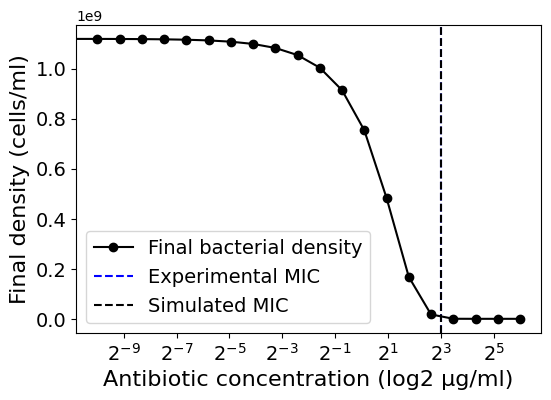


DATA MIC for Jing3: 8.0
Optimal kappa value for Jing3 is: 0.032919312679410055
The simulated MIC99 value for Jing3 is: 8.000000398688195 µg/ml


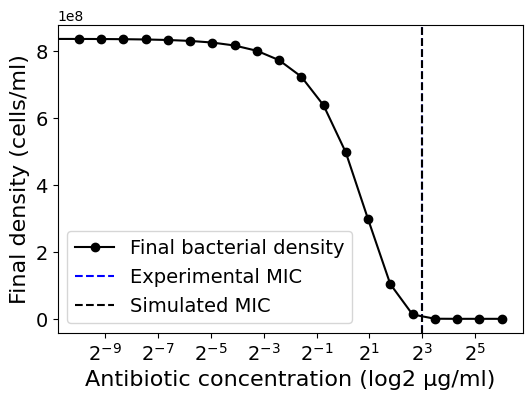


DATA MIC for Jing4: 8.0
Optimal kappa value for Jing4 is: 0.0512215457663949
The simulated MIC99 value for Jing4 is: 7.963093320913618 µg/ml


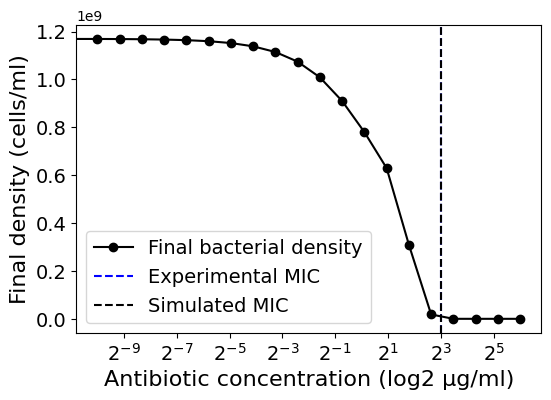


DATA MIC for Jing5: 0.5
Optimal kappa value for Jing5 is: 6.947466166116259
The simulated MIC99 value for Jing5 is: 0.031805048910860945 µg/ml


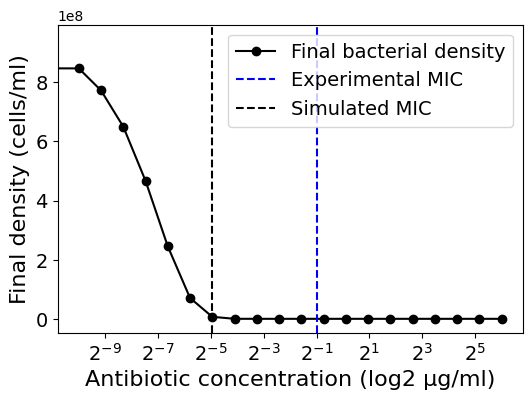


DATA MIC for Jing6: 0.5
Optimal kappa value for Jing6 is: 0.539605764024784
The simulated MIC99 value for Jing6 is: 0.46584243040489914 µg/ml


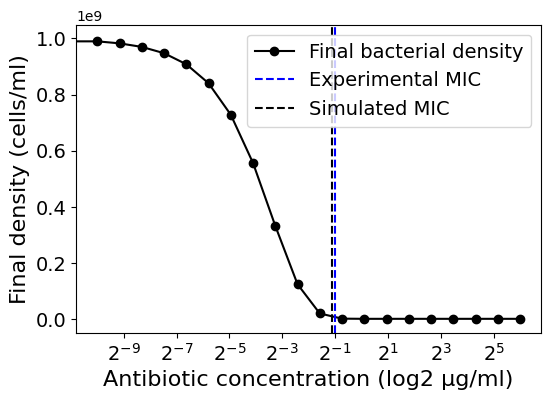


DATA MIC for Jing7: 2.0
Optimal kappa value for Jing7 is: 0.498475603842806
The simulated MIC99 value for Jing7 is: 0.4649352750911442 µg/ml


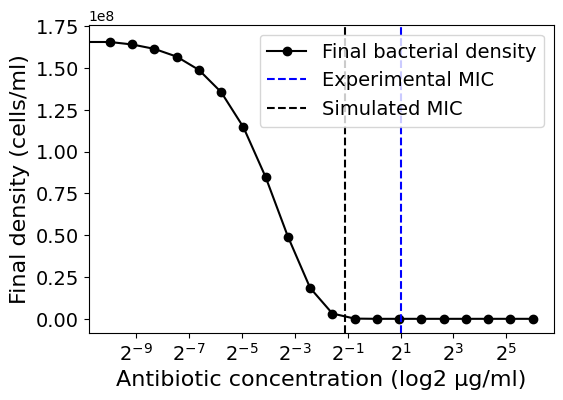


DATA MIC for Jing8: 0.5
Optimal kappa value for Jing8 is: 4.622906740458024
The simulated MIC99 value for Jing8 is: 0.06671371207238933 µg/ml


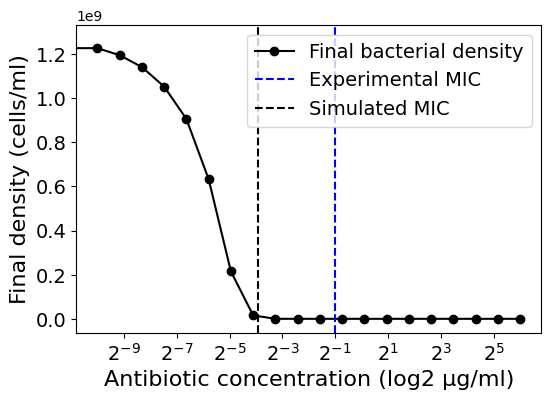

No MIC data found for Jing9
Strain: Jing2, Optimal kappa: 0.03664679176878976
Strain: Jing3, Optimal kappa: 0.032919312679410055
Strain: Jing4, Optimal kappa: 0.0512215457663949
Strain: Jing5, Optimal kappa: 6.947466166116259
Strain: Jing6, Optimal kappa: 0.539605764024784
Strain: Jing7, Optimal kappa: 0.498475603842806
Strain: Jing8, Optimal kappa: 4.622906740458024


In [73]:
import warnings


MIC_max = 1  #

# Suppress the specific RuntimeWarning from scipy.optimize._numdiff
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in subtract")

def load_mic_data(sheet_url, tab_name_mic, strain):
    """
    Load the MIC data for a specific strain from a Google Sheets URL.

    Parameters
    ----------
    sheet_url : str
        The URL of the Google Sheets document.
    tab_name_mic : str
        The tab name in the Google Sheets document.
    strain : str
        The name of the strain to filter the MIC data.

    Returns
    -------
    float
        The MIC value for the specified strain.
    """
    csv_export_url = f"{sheet_url}/gviz/tq?tqx=out:csv&sheet={tab_name_mic}"
    mic_data = pd.read_csv(csv_export_url)
    strain_mic = mic_data[mic_data['Strain'] == strain]['MIC']
    if not strain_mic.empty:
        return strain_mic.values[0]
    else:
        return None
k=0.7
ini_kappa=[0.03, 0.03, 0.03, 0.03, 0.7, 0.7, 0.08,0.7]
A_values = np.logspace(start=-10, stop=6, num=20, base=2)  # From 0.1 to 100 with 20 points
A_values = A_values.tolist()
A_values.insert(0, 0)
print(A_values)
y0 = [1.0, 1e6]  # Initial conditions for [R, B]
t = np.linspace(0, 24, 100)  # Time points
# Define a list to store the kappa values for each strain
kappa_values = []

# Fit kappa and simulate dose response for each strain
istrain=0
for strain, params in growth_params.items():
    rho = params['rho']
    muK = params['muK']

    # Load MIC data for the strain
    mic_value = load_mic_data(sheet_url, 'MIC', strain)
    if mic_value is not None:
        exp_MIC99 = mic_value
        print(f"\nDATA MIC for {strain}: {mic_value}")

        # Fit kappa with explicit bounds
        optimal_kappa = fit_kappa(rho, muK, y0, t, MIC_max, A_values, exp_MIC99, initial_kappa=ini_kappa[istrain], kappa_bounds=(1e-6, 1e6))
        print(f"Optimal kappa value for {strain} is: {optimal_kappa}")

        # Store the optimal kappa value in the list
        kappa_values.append((strain, optimal_kappa))

        # Simulate dose response with optimal kappa
        results = simulate_dose_response(rho, muK, optimal_kappa, y0, t, MIC_max, A_values)

        # Get the simulated MIC99
        sim_MIC99 = get_MIC(results)
        print(f"The simulated MIC99 value for {strain} is: {sim_MIC99} µg/ml")

        # Plot with annotations
        plot_dose_responseT(t, results, exp_MIC99=exp_MIC99, sim_MIC99=sim_MIC99)
    else:
        print(f"No MIC data found for {strain}")
    istrain+=1

# Print the stored kappa values
for strain, kappa in kappa_values:
    print(f"Strain: {strain}, Optimal kappa: {kappa}")
